# No PCA

## Import + data loading 

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')
from matplotlib.patches import Patch
sns.set_style("whitegrid")

#Parameters
filter=False

# LOAD DATA
GITHUB_BASE = "https://raw.githubusercontent.com/AyaanTigdikar/Capstone/main/MASTER/"
master = pd.read_csv(f"{GITHUB_BASE}Master.csv").drop(columns=['Unnamed: 0'], errors='ignore')
print(f"Master: {len(master)} obs, {master['Country Code'].nunique()} countries")
# PREPARE PANEL
df = master[(master['Year'] >= 1995) & (master['Year'] <= 2019)].dropna(subset=['Economic Complexity Index']).copy()
df = df.sort_values(['Country Code', 'Year'])
resource_rich_countries = master[master['Year'] == 1995][
    master[master['Year'] == 1995]['Total natural resources rents (% of GDP)'] >= 5
]['Country Code'].unique()
if filter:
    df = df[df['Country Code'].isin(resource_rich_countries)]
df['Resource_Rich'] = df['Country Code'].isin(resource_rich_countries).astype(int)





Master: 3150 obs, 126 countries


## Model

In [39]:
# Interactions
df['HCI_x_ProductionValue'] = df['Human capital index'] * df['Total_Production_Value']
df['RuleOfLaw_x_ProductionValue'] = df['Rule of law index'] * df['Total_Production_Value']


# FEATURES (with STATIC PCA, not time-varying)
base_features = [
    'Human capital index', 'Rule of law index', 'Political stability — estimate',
    'Trade (% of GDP)', 'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Share of investment in GDP',
    'Domestic credit to private sector (% of GDP)', 'Landlocked',
    'Urban population (% of total population)', 'Government revenue',
    'Capital depreciation rate', 'Use of IMF credit (DOD, current US$)', 'Services',
    'Real interest rate (%)', 'Inflation, consumer prices (annual %)',
    'Access to electricity (% of population)', 'Adjusted savings: gross savings (% of GNI)'
]
nat_int = [
    'Total natural resources rents (% of GDP)',
    'Oil rents (% of GDP)',
    'Mineral rents (% of GDP)',
    'Natural gas rents (% of GDP)'
]
if filter:
    all_features = base_features + nat_int+ ['HCI_x_ProductionValue', 'RuleOfLaw_x_ProductionValue']
else:
    all_features = base_features + ['Resource_Rich','HCI_x_ProductionValue', 'RuleOfLaw_x_ProductionValue']
print(f"Total features: {len(all_features)} (17 base + 1 group + 2 interactions)")

y = df['Economic Complexity Index'].values
X = df[all_features].copy()
years = df['Year'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

# Split
train_mask = years <= 2014
X_train, X_test = X_scaled[train_mask], X_scaled[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# Train
tscv = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=tscv).fit(X_train, y_train)
elastic = ElasticNetCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=10, 
                           random_state=42, n_jobs=-1, oob_score=True).fit(X_train, y_train)

models = {'LASSO': lasso, 'Ridge': ridge, 'Elastic Net': elastic, 'Random Forest': rf}

print("All models trained")

# Collect importance
all_importance = pd.DataFrame({'Feature': all_features})
feature_signs = pd.DataFrame({'Feature': all_features})
for name, model in models.items():
    if name in ['LASSO', 'Ridge', 'Elastic Net']:
        all_importance[name] = np.abs(model.coef_)
        feature_signs[name] = np.sign(model.coef_)
    else:
        all_importance[name] = model.feature_importances_
        feature_signs[name] = 1.0
all_importance['Average'] = all_importance[['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']].mean(axis=1)

# Performance
perf = []
for name, model in models.items():
    perf.append({
        'Model': name,
        'Test_R2': model.score(X_test, y_test),
        'Train_R2': model.score(X_train, y_train)
    })
perf_df = pd.DataFrame(perf).sort_values('Test_R2', ascending=False)

print("Importance collected from all models")

Total features: 20 (17 base + 1 group + 2 interactions)
All models trained
Importance collected from all models


## Graphics

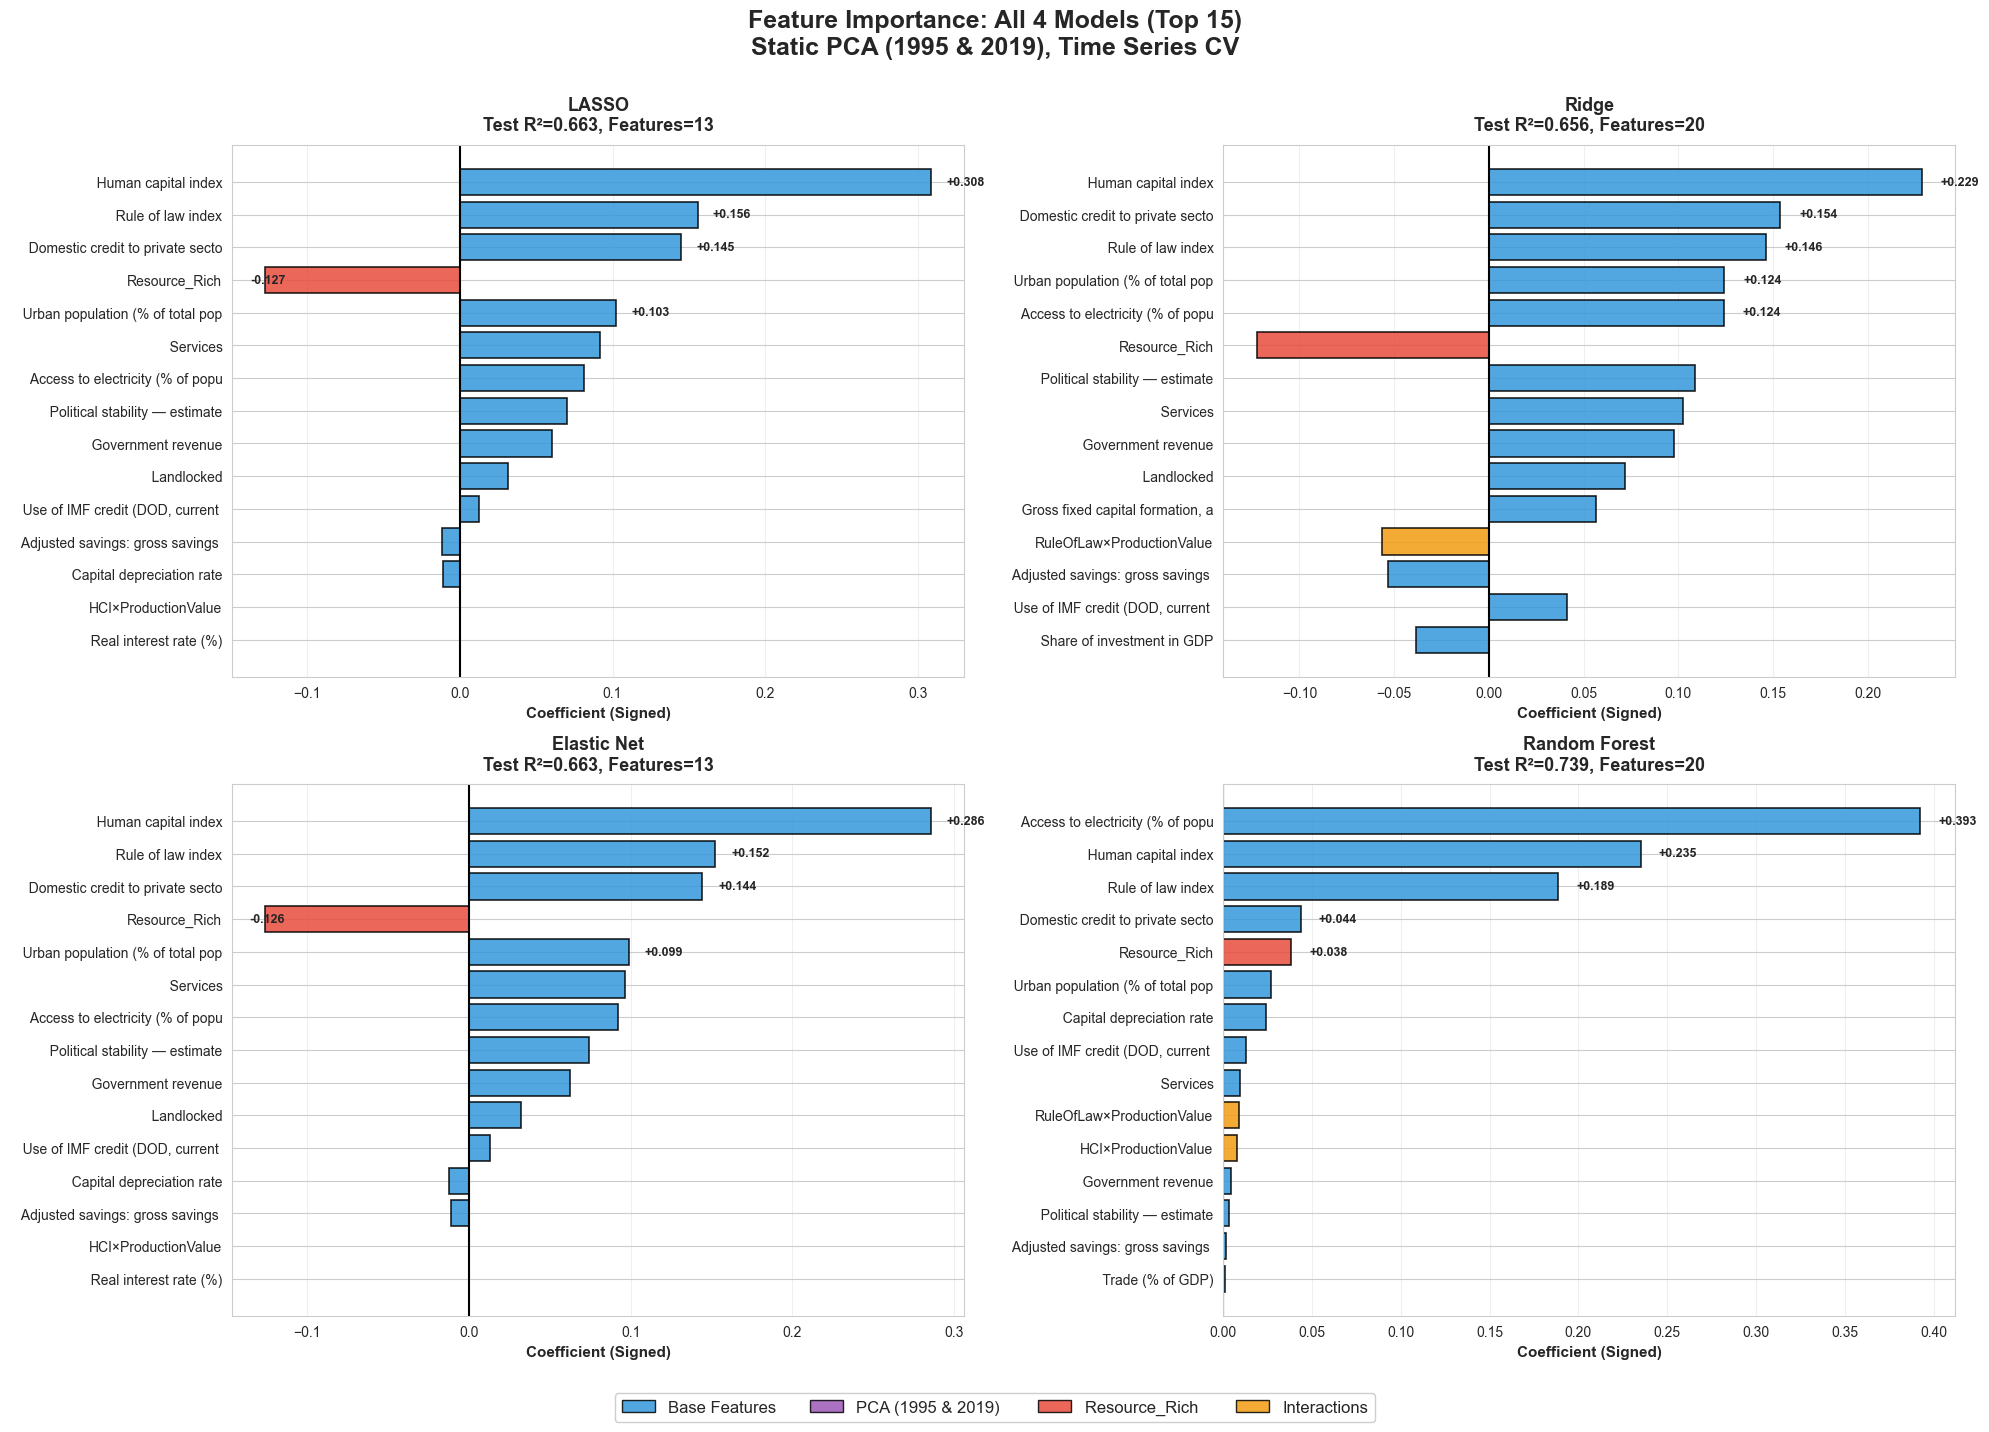


[2/6] Heatmap (top 20 features)...


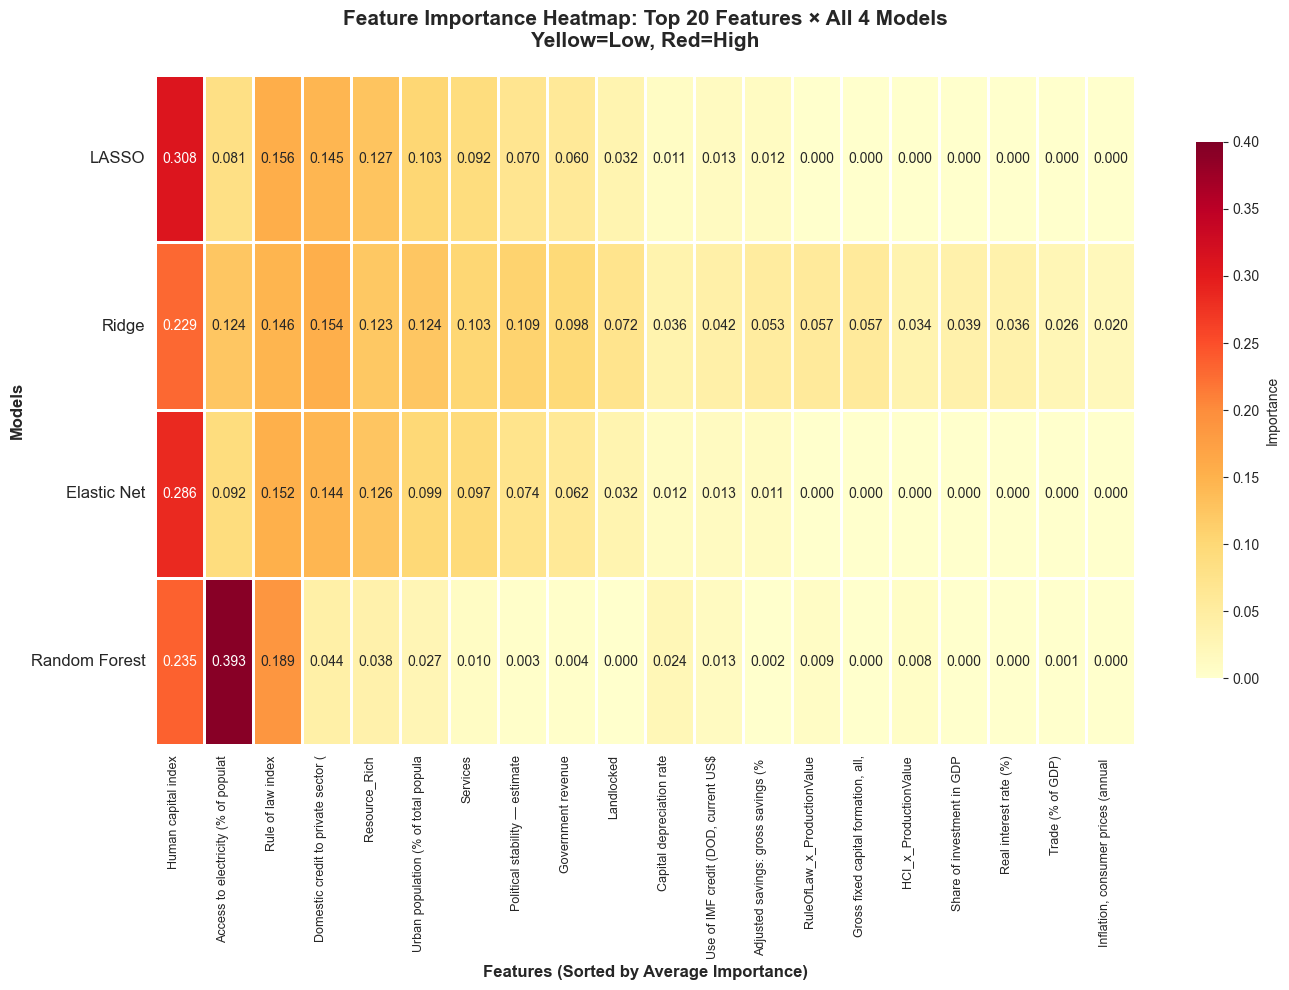


[3/6] Grouped bar chart (top 10)...


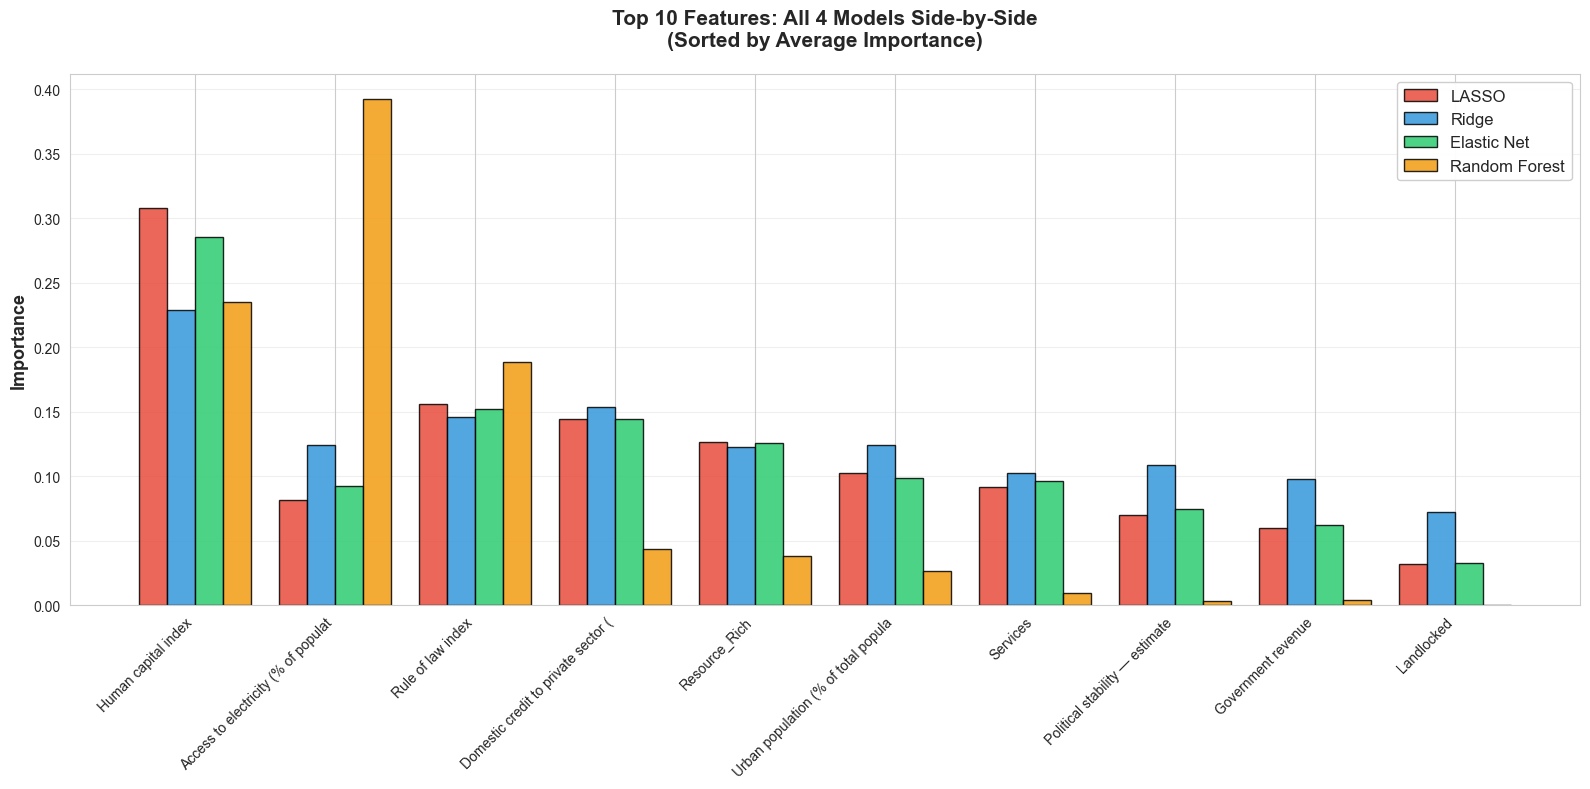


[6/6] Model agreement plot...


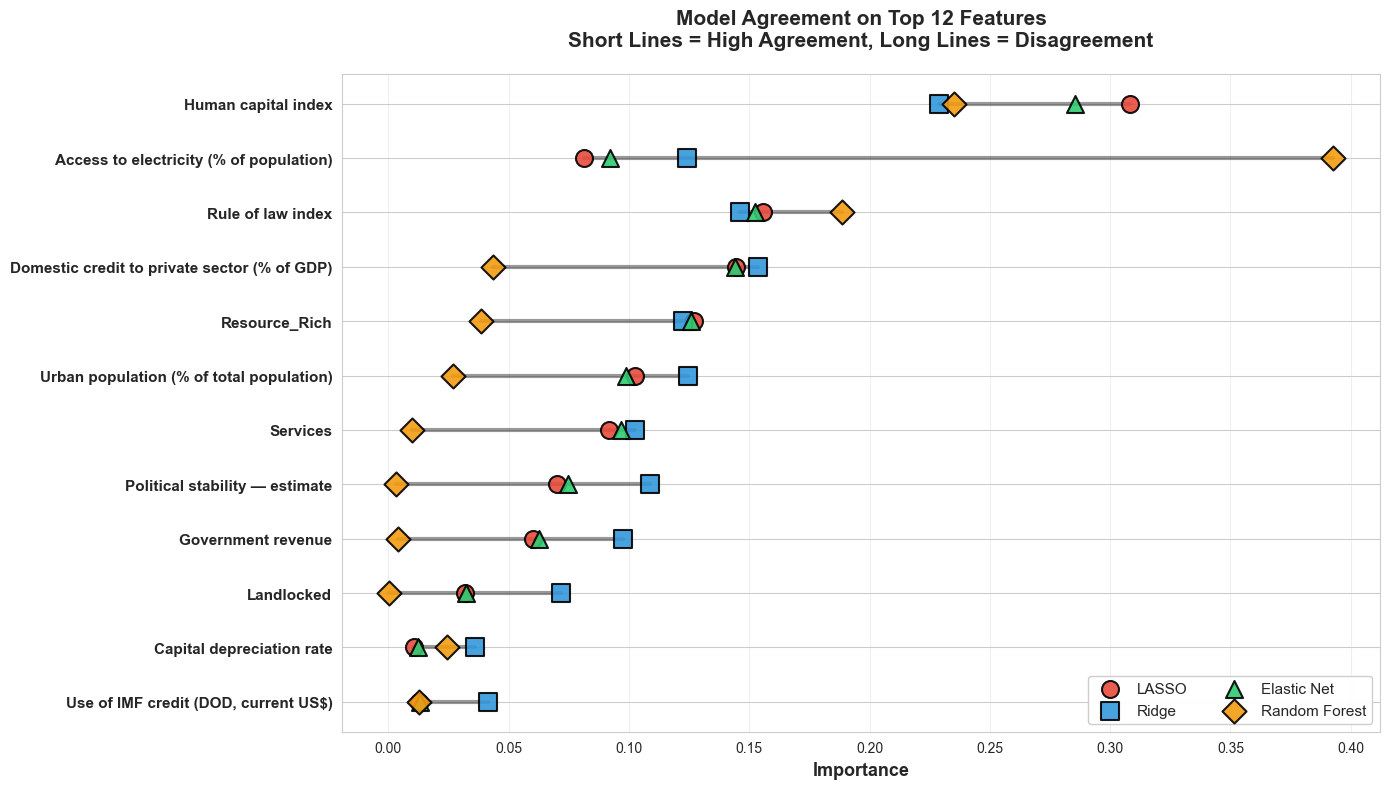


Model Performance:
        Model  Test_R2  Train_R2
Random Forest   0.7393    0.8483
  Elastic Net   0.6628    0.7336
        LASSO   0.6626    0.7343
        Ridge   0.6562    0.7497

TOP 10 CONSENSUS (Average Across All Models):

1. Human capital index
   LASSO: 0.3081, Ridge: 0.2287, Elastic: 0.2855, RF: 0.2352
   Average: 0.2644
   Agreement: ✅ High (CV=0.13)

2. Access to electricity (% of population)
   LASSO: 0.0813, Ridge: 0.1240, Elastic: 0.0921, RF: 0.3926
   Average: 0.1725
   Agreement: ✗ Low (CV=0.74)

3. Rule of law index
   LASSO: 0.1557, Ridge: 0.1461, Elastic: 0.1523, RF: 0.1887
   Average: 0.1607
   Agreement: ✅ High (CV=0.10)

4. Domestic credit to private sector (% of GDP)
   LASSO: 0.1446, Ridge: 0.1538, Elastic: 0.1440, RF: 0.0437
   Average: 0.1215
   Agreement: ○ Medium (CV=0.37)

5. Resource_Rich
   LASSO: 0.1269, Ridge: 0.1227, Elastic: 0.1258, RF: 0.0384
   Average: 0.1034
   Agreement: ○ Medium (CV=0.36)

6. Urban population (% of total population)
   LASSO

In [40]:
# VISUALIZATION 1: 4-Panel Top 15
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()


# REPLACE THE ENTIRE VISUALIZATION 1 SECTION:

for idx, model_name in enumerate(['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']):
    ax = axes[idx]
    
    # Get top 15 by ABSOLUTE value but keep SIGNS
    if model_name in ['LASSO', 'Ridge', 'Elastic Net']:
        signed_vals = models[model_name].coef_
        abs_vals = np.abs(signed_vals)
        top_15_idx = np.argsort(abs_vals)[::-1][:15]
        
        top_15_features = [all_features[i] for i in top_15_idx]
        top_15_values = signed_vals[top_15_idx]  # SIGNED values!
    else:
        model_sorted = all_importance.sort_values(model_name, ascending=False).head(15)
        top_15_features = model_sorted['Feature'].tolist()
        top_15_values = model_sorted[model_name].values
    
    # Build colors and labels using top_15_features
    colors = []
    labels = []
    for feat in top_15_features:  # Changed from model_sorted['Feature']
        if 'PCA' in feat or ('PC' in feat and '_x_' not in feat):
            colors.append('#9B59B6')
            label_text = f"{feat[:32]}"
        elif '_x_' in feat:
            colors.append('#F39C12')
            label_text = f"{feat.replace('_x_', '×')[:32]}"
        elif 'Resource_Rich' in feat:
            colors.append('#E74C3C')
            label_text = f"{feat[:32]}"
        else:
            colors.append('#3498DB')
            label_text = f"   {feat[:32]}"
        labels.append(label_text)
    
    y_pos = np.arange(len(top_15_features))
    bars = ax.barh(y_pos, top_15_values, color=colors, alpha=0.85,  # SIGNED!
                  edgecolor='black', linewidth=1.2)
    
    ax.axvline(0, color='black', linewidth=1.5)  # Zero line
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Coefficient (Signed)', fontsize=11, fontweight='bold')
    test_r2 = perf_df[perf_df['Model'] == model_name]['Test_R2'].values[0]
    n_features = len(all_features) if model_name in ['Ridge', 'Random Forest'] else np.sum(all_importance[model_name] != 0)
    ax.set_title(f'{model_name}\nTest R²={test_r2:.3f}, Features={n_features}', 
                fontsize=13, fontweight='bold', pad=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    # Add values for top 5
    for i in range(min(5, len(bars))):
        val = top_15_values[i]  # Changed from model_sorted
        if abs(val) > 0.01:
            x_pos = val + 0.01 if val > 0 else val - 0.01
            ax.text(x_pos, i, f'{val:+.3f}', va='center', fontsize=9, fontweight='bold')


fig.legend(handles=[
    Patch(facecolor='#3498DB', label='Base Features', alpha=0.85, edgecolor='black'),
    Patch(facecolor='#9B59B6', label='PCA (1995 & 2019) ', alpha=0.85, edgecolor='black'),
    Patch(facecolor='#E74C3C', label='Resource_Rich ', alpha=0.85, edgecolor='black'),
    Patch(facecolor='#F39C12', label='Interactions', alpha=0.85, edgecolor='black')
], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=12, framealpha=0.95)

plt.suptitle('Feature Importance: All 4 Models (Top 15)\nStatic PCA (1995 & 2019), Time Series CV', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

# VISUALIZATION 2: Heatmap (Top 20)
print("\n[2/6] Heatmap (top 20 features)...")

fig, ax = plt.subplots(figsize=(14, 10))

top_20 = all_importance.sort_values('Average', ascending=False).head(20)
heatmap_matrix = top_20[['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']].T

sns.heatmap(heatmap_matrix, annot=True, fmt='.3f', cmap='YlOrRd', 
           cbar_kws={'label': 'Importance', 'shrink': 0.8}, 
           linewidths=1, linecolor='white',
           xticklabels=[f[:35] for f in top_20['Feature']],
           yticklabels=['LASSO', 'Ridge', 'Elastic Net', 'Random Forest'],
           ax=ax, vmin=0, vmax=0.4)

ax.set_title('Feature Importance Heatmap: Top 20 Features × All 4 Models\nYellow=Low, Red=High', 
            fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Features (Sorted by Average Importance)', fontsize=12, fontweight='bold')
ax.set_ylabel('Models', fontsize=12, fontweight='bold')

plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

# VISUALIZATION 3: Grouped Bar (Top 10)

print("\n[3/6] Grouped bar chart (top 10)...")

fig, ax = plt.subplots(figsize=(16, 8))

top_10 = all_importance.sort_values('Average', ascending=False).head(10)

x = np.arange(len(top_10))
width = 0.2

ax.bar(x - 1.5*width, top_10['LASSO'], width, label='LASSO', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#E74C3C')
ax.bar(x - 0.5*width, top_10['Ridge'], width, label='Ridge', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#3498DB')
ax.bar(x + 0.5*width, top_10['Elastic Net'], width, label='Elastic Net', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#2ECC71')
ax.bar(x + 1.5*width, top_10['Random Forest'], width, label='Random Forest', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#F39C12')

ax.set_xticks(x)
ax.set_xticklabels([f[:35] for f in top_10['Feature']], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Importance', fontsize=13, fontweight='bold')
ax.set_title('Top 10 Features: All 4 Models Side-by-Side\n(Sorted by Average Importance)', 
            fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper right', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# VISUALIZATION 6: Model Agreement with Ranges

print("\n[6/6] Model agreement plot...")
fig, ax = plt.subplots(figsize=(14, 8))
top_12 = all_importance.sort_values('Average', ascending=False).head(12)

# For each feature, plot model values and range
y_pos = np.arange(len(top_12))

for i, (_, row) in enumerate(top_12.iterrows()):
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net'], row['Random Forest']]
    
    # Plot range line
    ax.plot([min(vals), max(vals)], [i, i], 'k-', alpha=0.4, linewidth=3, zorder=1)
    
    # Plot model points
    ax.scatter(row['LASSO'], i, marker='o', s=150, alpha=0.9, 
              color='#E74C3C', edgecolor='black', linewidth=1.5, zorder=3, label='LASSO' if i==0 else '')
    ax.scatter(row['Ridge'], i, marker='s', s=150, alpha=0.9, 
              color='#3498DB', edgecolor='black', linewidth=1.5, zorder=3, label='Ridge' if i==0 else '')
    ax.scatter(row['Elastic Net'], i, marker='^', s=150, alpha=0.9, 
              color='#2ECC71', edgecolor='black', linewidth=1.5, zorder=3, label='Elastic Net' if i==0 else '')
    ax.scatter(row['Random Forest'], i, marker='D', s=150, alpha=0.9, 
              color='#F39C12', edgecolor='black', linewidth=1.5, zorder=3, label='Random Forest' if i==0 else '')

ax.set_yticks(y_pos)
ax.set_yticklabels([f[:45] for f in top_12['Feature']], fontsize=11, fontweight='bold')
ax.set_xlabel('Importance', fontsize=13, fontweight='bold')
ax.set_title('Model Agreement on Top 12 Features\nShort Lines = High Agreement, Long Lines = Disagreement', 
            fontsize=15, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.legend(fontsize=11, loc='lower right', framealpha=0.95, ncol=2)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# SUMMARY STATISTICS
print("\nModel Performance:")
print(perf_df.to_string(index=False, float_format='%.4f'))

print("\n" + "="*80)
print("TOP 10 CONSENSUS (Average Across All Models):")
print("="*80)

for i, (_, row) in enumerate(top_10.iterrows(), 1):
    print(f"\n{i}. {row['Feature']}")
    print(f"   LASSO: {row['LASSO']:.4f}, Ridge: {row['Ridge']:.4f}, "
          f"Elastic: {row['Elastic Net']:.4f}, RF: {row['Random Forest']:.4f}")
    print(f"   Average: {row['Average']:.4f}")
    
    # Calculate coefficient of variation (measure of agreement)
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net'], row['Random Forest']]
    cv = np.std(vals) / np.mean(vals) if np.mean(vals) > 0 else 0
    agreement = "✅ High" if cv < 0.3 else "○ Medium" if cv < 0.6 else "✗ Low"
    print(f"   Agreement: {agreement} (CV={cv:.2f})")

print("\n" + "="*80)
print("PCA COMPONENTS (All Models):")
print("="*80)

for feat in ['PC1_1995', 'PC2_1995', 'PC1_2019', 'PC2_2019', 'PCA_Distance']:
    if feat in all_importance['Feature'].values:
        row = all_importance[all_importance['Feature'] == feat].iloc[0]
        rank = all_importance.sort_values('Average', ascending=False)[
            all_importance.sort_values('Average', ascending=False)['Feature'] == feat
        ].index[0] + 1
        
        print(f"\n{feat}:")
        print(f"   LASSO: {row['LASSO']:.4f}, Ridge: {row['Ridge']:.4f}, "
              f"Elastic: {row['Elastic Net']:.4f}, RF: {row['Random Forest']:.4f}")
        print(f"   Average: {row['Average']:.4f} (Rank #{rank}/{len(all_features)})")

print("\n" + "="*80)
print("COEFFICIENT SIGNS (Top 15):")
print("="*80)

top_15_list = all_importance.sort_values('Average', ascending=False).head(15)
for i, (_, row) in enumerate(top_15_list.iterrows(), 1):
    feat = row['Feature']
    sign_row = feature_signs[feature_signs['Feature'] == feat].iloc[0]
    
    lasso_sign = '+' if sign_row['LASSO'] > 0 else '-' if sign_row['LASSO'] < 0 else '0'
    ridge_sign = '+' if sign_row['Ridge'] > 0 else '-' if sign_row['Ridge'] < 0 else '0'
    elastic_sign = '+' if sign_row['Elastic Net'] > 0 else '-' if sign_row['Elastic Net'] < 0 else '0'
    
    print(f"\n{i:2d}. {feat[:50]}")
    print(f"    Signs: LASSO:{lasso_sign}  Ridge:{ridge_sign}  Elastic:{elastic_sign}")
    print(f"    Import: L:{row['LASSO']:.3f} R:{row['Ridge']:.3f} E:{row['Elastic Net']:.3f} RF:{row['Random Forest']:.3f}")

# Tried generating the PCA for every year

## Import libraries and data

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')
from matplotlib.patches import Patch

sns.set_style("whitegrid")

# ============================================================================
# LOAD DATA FROM GITHUB
# ============================================================================

print("="*80)
print("LOADING DATA FROM GITHUB")
print("="*80)

GITHUB_BASE = "https://raw.githubusercontent.com/AyaanTigdikar/Capstone/refs/heads/main/MASTER/"

master = pd.read_csv(f"{GITHUB_BASE}Master.csv").drop(columns=['Unnamed: 0'], errors='ignore')
print(f"✓ Master.csv: {len(master)} obs, {master['Country Code'].nunique()} countries")

nr = pd.read_csv(f"{GITHUB_BASE}NaturalResource.csv", index_col=0)
print(f"✓ NaturalResource.csv: {len(nr)} obs")

# Include list (resource-rich countries)
include_list = ['AGO', 'ARE', 'AZE', 'BFA', 'BHR', 'BOL', 'CHL', 'CIV', 'CMR',
       'COD', 'COG', 'DZA', 'ECU', 'EGY', 'ETH', 'GAB', 'GHA', 'GIN',
       'GNQ', 'IDN', 'IRN', 'IRQ', 'KAZ', 'KEN', 'KWT', 'LAO', 'LBR',
       'LBY', 'MDG', 'MLI', 'MMR', 'MNG', 'MOZ', 'MWI', 'MYS', 'NER',
       'NGA', 'OMN', 'PNG', 'QAT', 'RUS', 'RWA', 'SAU', 'TCD', 'TGO',
       'TTO', 'TZA', 'UGA', 'UZB', 'VEN', 'VNM', 'YEM', 'ZMB', 'ZWE']

nr = nr[nr["Country Code"].isin(include_list)]
print(f"✓ Filtered to {len(include_list)} resource-rich countries")

LOADING DATA FROM GITHUB
✓ Master.csv: 3150 obs, 126 countries
✓ NaturalResource.csv: 17166 obs
✓ Filtered to 54 resource-rich countries


## PCA 

In [42]:
# Get 1995 data
nr_1995 = nr[nr['Year'] == 1995].copy()

# Pivot to get resource columns
df_pivot_1995 = nr_1995.pivot_table(
    index=['Country', 'Country Code', 'Year', 'Population'],
    columns='Resource',
    values='Production_TotalValue'
).reset_index()

# Normalize by population (per capita)
resource_cols = df_pivot_1995.columns.difference(['Country', 'Country Code', 'Year', 'Population'])
df_pivot_1995[resource_cols] = df_pivot_1995[resource_cols].div(df_pivot_1995['Population'], axis=0)
df_pivot_1995 = df_pivot_1995.drop(columns='Population')
df_pivot_1995 = df_pivot_1995.fillna(0)

print(f"✓ 1995 pivot: {len(df_pivot_1995)} countries, {len(resource_cols)} resources")
print(f"  Resources: {', '.join(list(resource_cols)[:5])}...")

# Prepare for PCA
X_1995 = df_pivot_1995[resource_cols].values

# Standardize
scaler_production = StandardScaler()
X_1995_scaled = scaler_production.fit_transform(X_1995)

# Fit PCA (2 components as per your request)
pca = PCA(n_components=2, random_state=42)
pca_components_1995 = pca.fit_transform(X_1995_scaled)

print(f"\nPCA Explained Variance:")
for i, var in enumerate(pca.explained_variance_ratio_):
    cumulative = pca.explained_variance_ratio_[:i+1].sum()
    print(f"  PC{i+1}: {var*100:.1f}% (cumulative: {cumulative*100:.1f}%)")

print(f"\n✓ PCA fitted on 1995 resource production patterns")
print(f"  Using {pca.n_components} PCs for analysis")
print(f"  Explains {pca.explained_variance_ratio_.sum()*100:.1f}% of variance")

# Save 1995 PCA scores
df_pivot_1995['PC1_1995_fitted'] = pca_components_1995[:, 0]
df_pivot_1995['PC2_1995_fitted'] = pca_components_1995[:, 1]


# APPLY SAME PCA TO ALL YEARS (Rolling)
print("\n" + "="*80)
print("APPLYING 1995 PCA TO ALL YEARS (1995-2019)")
print("="*80)

# Store PCA scores for all years
pca_scores_all_years = []

for year in range(1995, 2020):
    nr_year = nr[nr['Year'] == year].copy()
    
    if len(nr_year) == 0:
        continue
    
    # Pivot for this year
    df_pivot_year = nr_year.pivot_table(
        index=['Country', 'Country Code', 'Year', 'Population'],
        columns='Resource',
        values='Production_TotalValue'
    ).reset_index()
    
    # Normalize by population
    resource_cols_year = df_pivot_year.columns.difference(['Country', 'Country Code', 'Year', 'Population'])
    df_pivot_year[resource_cols_year] = df_pivot_year[resource_cols_year].div(df_pivot_year['Population'], axis=0)
    df_pivot_year = df_pivot_year.drop(columns='Population')
    df_pivot_year = df_pivot_year.fillna(0)
    
    # Ensure same columns as 1995
    for col in resource_cols:
        if col not in df_pivot_year.columns:
            df_pivot_year[col] = 0
    
    # Transform using 1995 PCA
    X_year = df_pivot_year[resource_cols].values
    X_year_scaled = scaler_production.transform(X_year)
    pca_components_year = pca.transform(X_year_scaled)
    
    # Save scores
    df_pivot_year['PC1_fitted'] = pca_components_year[:, 0]
    df_pivot_year['PC2_fitted'] = pca_components_year[:, 1]
    
    pca_scores_all_years.append(df_pivot_year[['Country Code', 'Year', 'PC1_fitted', 'PC2_fitted']])

# Combine all years
pca_scores_df = pd.concat(pca_scores_all_years, ignore_index=True)

print(f"✓ Applied 1995 PCA to all years")
print(f"  Years covered: {pca_scores_df['Year'].min()}-{pca_scores_df['Year'].max()}")
print(f"  Total observations: {len(pca_scores_df)}")

# MERGE PCA WITH MASTER DATA
# Prepare panel
mask = (master['Year'] == 1995) & (master['Total natural resources rents (% of GDP)'] >= 5)
target_countries = master[mask]['Country Code'].unique()
master = master[master['Country Code'].isin(target_countries)]
df = master[(master['Year'] >= 1995) & (master['Year'] <= 2019)].dropna(subset=['Economic Complexity Index']).copy()
df = df.sort_values(['Country Code', 'Year'])

# Merge PCA scores
df = df.merge(pca_scores_df, on=['Country Code', 'Year'], how='left')
# Get 1995 baseline for distance calculation
pca_1995_baseline = pca_scores_df[pca_scores_df['Year'] == 1995][
    ['Country Code', 'PC1_fitted', 'PC2_fitted']
].rename(columns={'PC1_fitted': 'PC1_1995', 'PC2_fitted': 'PC2_1995'})
df = df.merge(pca_1995_baseline, on='Country Code', how='left')
# Rename for consistency
df = df.rename(columns={'PC1_fitted': 'PC1_t', 'PC2_fitted': 'PC2_t'})

# Calculate time-varying distance (from 1995 to current year)
df['PCA_Distance_t'] = np.sqrt(
    (df['PC1_t'] - df['PC1_1995'])**2 +
    (df['PC2_t'] - df['PC2_1995'])**2
)

print(f"✓ PCA scores merged with panel")
print(f"  Observations with PCA: {df['PC1_t'].notna().sum()}")




✓ 1995 pivot: 52 countries, 20 resources
  Resources: Aluminium, Bauxite, Cadmium, Coal, Cobalt...

PCA Explained Variance:
  PC1: 19.7% (cumulative: 19.7%)
  PC2: 17.8% (cumulative: 37.5%)

✓ PCA fitted on 1995 resource production patterns
  Using 2 PCs for analysis
  Explains 37.5% of variance

APPLYING 1995 PCA TO ALL YEARS (1995-2019)
✓ Applied 1995 PCA to all years
  Years covered: 1995-2019
  Total observations: 1319
✓ PCA scores merged with panel
  Observations with PCA: 1319


## Model

In [43]:
# Interactions
df['HCI_x_ProductionValue'] = df['Human capital index'] * df['Total_Production_Value']
df['RuleOfLaw_x_ProductionValue'] = df['Rule of law index'] * df['Total_Production_Value']

# FEATURES
base_features = [
    'Human capital index', 'Rule of law index', 'Political stability — estimate',
    'Trade (% of GDP)', 'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Share of investment in GDP',
    'Domestic credit to private sector (% of GDP)', 'Landlocked',
    'Urban population (% of total population)', 'Government revenue',
    'Capital depreciation rate', 'Use of IMF credit (DOD, current US$)', 'Services',
    'Real interest rate (%)', 'Inflation, consumer prices (annual %)',
    'Access to electricity (% of population)', 'Adjusted savings: gross savings (% of GNI)'
]

# I only tested these interactions btw
all_features = base_features + ['PC1_t','PC2_t', 'PCA_Distance_t',
                                'HCI_x_ProductionValue', 'RuleOfLaw_x_ProductionValue']

y = df['Economic Complexity Index'].values
X = df[all_features].copy()
years = df['Year'].values

for col in X.columns:
    if 'PC' in col:
        X[col] = X[col].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

# Split
train_mask = years <= 2014
X_train, X_test = X_scaled[train_mask], X_scaled[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# Train
tscv = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=tscv).fit(X_train, y_train)
elastic = ElasticNetCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=10, 
                           random_state=42, n_jobs=-1, oob_score=True).fit(X_train, y_train)

models = {'LASSO': lasso, 'Ridge': ridge, 'Elastic Net': elastic, 'Random Forest': rf}

print("\n" + "="*80)
print("All models trained")
print("="*80)

# Collect importance
all_importance = pd.DataFrame({'Feature': all_features})
for name, model in models.items():
    if name in ['LASSO', 'Ridge', 'Elastic Net']:
        all_importance[name] = np.abs(model.coef_)
    else:
        all_importance[name] = model.feature_importances_
all_importance['Average'] = all_importance[['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']].mean(axis=1)

# Performance
perf = []
for name, model in models.items():
    perf.append({
        'Model': name,
        'Test_R2': model.score(X_test, y_test),
        'Train_R2': model.score(X_train, y_train)
    })
perf_df = pd.DataFrame(perf).sort_values('Test_R2', ascending=False)

print("Importance collected from all models")



All models trained
Importance collected from all models


In [44]:
# VISUALIZATION 1: 4-Panel Top 15
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for idx, model_name in enumerate(['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']):
    ax = axes[idx]
    
    model_sorted = all_importance.sort_values(model_name, ascending=False).head(15)
    colors = []
    labels = []
    for feat in model_sorted['Feature']:
        if 'PCA' in feat or ('PC' in feat and '_x_' not in feat):
            colors.append('#9B59B6')
            label_text = f"{feat[:32]}"
        elif '_x_' in feat:
            colors.append('#F39C12')
            label_text = f"{feat.replace('_x_', '×')[:32]}"
        elif 'Resource_Rich' in feat:
            colors.append('#E74C3C')
            label_text = f"{feat[:32]}"
        else:
            colors.append('#3498DB')
            label_text = f"   {feat[:32]}"
        labels.append(label_text)
    
    y_pos = np.arange(len(model_sorted))
    bars = ax.barh(y_pos, model_sorted[model_name], color=colors, alpha=0.85, 
                  edgecolor='black', linewidth=1.2)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
    test_r2 = perf_df[perf_df['Model'] == model_name]['Test_R2'].values[0]
    n_features = len(all_features) if model_name in ['Ridge', 'Random Forest'] else np.sum(all_importance[model_name] != 0)
    ax.set_title(f'{model_name}\nTest R²={test_r2:.3f}, Features={n_features}', 
                fontsize=13, fontweight='bold', pad=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    # Add values for top 5
    for i in range(min(5, len(bars))):
        val = model_sorted[model_name].iloc[i]
        if val > 0.01:
            ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')


fig.legend(handles=[
    Patch(facecolor='#3498DB', label='Base Features', alpha=0.85, edgecolor='black'),
    Patch(facecolor='#9B59B6', label='PCA (Production-Based) ', alpha=0.85, edgecolor='black'),
    Patch(facecolor='#E74C3C', label='Resource_Rich ', alpha=0.85, edgecolor='black'),
    Patch(facecolor='#F39C12', label='Interactions ', alpha=0.85, edgecolor='black')
], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=12, framealpha=0.95)

plt.suptitle('Feature Importance: All 4 Models (Top 15)\nPCA from Individual Resource Production (Per Capita), Time Series CV', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

# VISUALIZATION 2: Heatmap (Top 20)
print("\n[2/5] Heatmap (top 20 features)...")

fig, ax = plt.subplots(figsize=(14, 10))

top_20 = all_importance.sort_values('Average', ascending=False).head(20)
heatmap_matrix = top_20[['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']].T

sns.heatmap(heatmap_matrix, annot=True, fmt='.3f', cmap='YlOrRd', 
           cbar_kws={'label': 'Importance', 'shrink': 0.8}, 
           linewidths=1, linecolor='white',
           xticklabels=[f[:35] for f in top_20['Feature']],
           yticklabels=['LASSO', 'Ridge', 'Elastic Net', 'Random Forest'],
           ax=ax, vmin=0, vmax=0.4)

ax.set_title('Feature Importance Heatmap: Top 20 Features × All 4 Models\nYellow=Low, Red=High', 
            fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Features (Sorted by Average Importance)', fontsize=12, fontweight='bold')
ax.set_ylabel('Models', fontsize=12, fontweight='bold')

plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

# VISUALIZATION 3: Grouped Bar (Top 10)

print("\n[3/5] Grouped bar chart (top 10)...")

fig, ax = plt.subplots(figsize=(16, 8))

top_10 = all_importance.sort_values('Average', ascending=False).head(10)

x = np.arange(len(top_10))
width = 0.2

ax.bar(x - 1.5*width, top_10['LASSO'], width, label='LASSO', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#E74C3C')
ax.bar(x - 0.5*width, top_10['Ridge'], width, label='Ridge', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#3498DB')
ax.bar(x + 0.5*width, top_10['Elastic Net'], width, label='Elastic Net', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#2ECC71')
ax.bar(x + 1.5*width, top_10['Random Forest'], width, label='Random Forest', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#F39C12')

ax.set_xticks(x)
ax.set_xticklabels([f[:35] for f in top_10['Feature']], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Importance', fontsize=13, fontweight='bold')
ax.set_title('Top 10 Features: All 4 Models Side-by-Side\n(Sorted by Average Importance)', 
            fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper right', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# VISUALIZATION 4: Model Agreement with Ranges
print("\n[4/5] Model agreement plot...")

fig, ax = plt.subplots(figsize=(14, 8))
top_12 = all_importance.sort_values('Average', ascending=False).head(12)

# For each feature, plot model values and range
y_pos = np.arange(len(top_12))

for i, (_, row) in enumerate(top_12.iterrows()):
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net'], row['Random Forest']]
    
    # Plot range line
    ax.plot([min(vals), max(vals)], [i, i], 'k-', alpha=0.4, linewidth=3, zorder=1)
    
    # Plot model points
    ax.scatter(row['LASSO'], i, marker='o', s=150, alpha=0.9, 
              color='#E74C3C', edgecolor='black', linewidth=1.5, zorder=3, label='LASSO' if i==0 else '')
    ax.scatter(row['Ridge'], i, marker='s', s=150, alpha=0.9, 
              color='#3498DB', edgecolor='black', linewidth=1.5, zorder=3, label='Ridge' if i==0 else '')
    ax.scatter(row['Elastic Net'], i, marker='^', s=150, alpha=0.9, 
              color='#2ECC71', edgecolor='black', linewidth=1.5, zorder=3, label='Elastic Net' if i==0 else '')
    ax.scatter(row['Random Forest'], i, marker='D', s=150, alpha=0.9, 
              color='#F39C12', edgecolor='black', linewidth=1.5, zorder=3, label='Random Forest' if i==0 else '')

ax.set_yticks(y_pos)
ax.set_yticklabels([f[:45] for f in top_12['Feature']], fontsize=11, fontweight='bold')
ax.set_xlabel('Importance', fontsize=13, fontweight='bold')
ax.set_title('Model Agreement on Top 12 Features\nShort Lines = High Agreement, Long Lines = Disagreement', 
            fontsize=15, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.legend(fontsize=11, loc='lower right', framealpha=0.95, ncol=2)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# VISUALIZATION 5: PCA Trajectory Example
print("\n[5/5] PCA transformation trajectory (sample countries)...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sample countries
sample_countries = ['KAZ', 'VNM', 'NGA', 'CHL', 'SAU']
sample_data = df[df['Country Code'].isin(sample_countries)]

# PC1 over time
ax = axes[0]
for country in sample_countries:
    country_data = sample_data[sample_data['Country Code'] == country]
    ax.plot(country_data['Year'], country_data['PC1_t'], marker='o', label=country, linewidth=2)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('PC1 (Resource Scale)', fontsize=12, fontweight='bold')
ax.set_title('PC1 Evolution Over Time\n(Same PCA Applied to All Years)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# PCA_Distance over time
ax = axes[1]
for country in sample_countries:
    country_data = sample_data[sample_data['Country Code'] == country]
    ax.plot(country_data['Year'], country_data['PCA_Distance_t'], marker='o', label=country, linewidth=2.5)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('PCA_Distance_t (from 1995)', fontsize=12, fontweight='bold')
ax.set_title('Resource Transformation Over Time\nCumulative Distance from 1995 Baseline', 
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.axhline(0, color='black', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

# SUMMARY STATISTICS

print("\n" + "="*80)
print("MODEL PERFORMANCE")
print("="*80)
print(perf_df.to_string(index=False, float_format='%.4f'))

print("\n" + "="*80)
print("TOP 10 CONSENSUS (Average Across All Models):")
print("="*80)

for i, (_, row) in enumerate(top_10.iterrows(), 1):
    print(f"\n{i}. {row['Feature']}")
    print(f"   LASSO: {row['LASSO']:.4f}, Ridge: {row['Ridge']:.4f}, "
          f"Elastic: {row['Elastic Net']:.4f}, RF: {row['Random Forest']:.4f}")
    print(f"   Average: {row['Average']:.4f}")
    
    # Calculate coefficient of variation (measure of agreement)
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net'], row['Random Forest']]
    cv = np.std(vals) / np.mean(vals) if np.mean(vals) > 0 else 0
    agreement = "High" if cv < 0.3 else "Medium" if cv < 0.6 else "Low"
    print(f"   Agreement: {agreement} (CV={cv:.2f})")

print("\n" + "="*80)
print("PCA COMPONENTS (All Models):")
print("="*80)

for feat in ['PC1_t', 'PC2_t', 'PCA_Distance_t']:
    row = all_importance[all_importance['Feature'] == feat].iloc[0]
    rank = all_importance.sort_values('Average', ascending=False)[
        all_importance.sort_values('Average', ascending=False)['Feature'] == feat
    ].index[0] + 1
    
    print(f"\n{feat}:")
    print(f"   LASSO: {row['LASSO']:.4f}, Ridge: {row['Ridge']:.4f}, "
          f"Elastic: {row['Elastic Net']:.4f}, RF: {row['Random Forest']:.4f}")
    print(f"   Average: {row['Average']:.4f} (Rank #{rank}/{len(all_features)})")
